In [29]:
import sys
import importlib
def reload_modules(*modules):
    for module in modules:
        if module.__name__ in sys.modules:
            importlib.reload(module)
        else:
            print(f"Module {module.__name__} is not currently imported.")

import numpy as np
import time
import copy
from PIL import Image
import cv2
import open3d as o3d
import importlib
import imutils
import matplotlib.pyplot as plt
from magpie_perception import pcd
from magpie_perception import utils
from magpie_perception.utils import label_wrist_image, find_object, label_wrist_image_rotation_axes
from magpie_control import realsense_wrapper as real
from magpie_control import ur5
from magpie_control import gripper
from magpie_control import poses
import spatialmath as sm
reload_modules(pcd, utils, real, ur5, gripper)

# rerun viz
import rerun as rr
from rerun_rlds_ur5.rlds import RLDSDataset, DeliGraspTrajectory, LiveRobotData
from rerun_rlds_ur5.rerun_loader_urdf import URDFLogger, get_urdf_paths, update_urdf
reload_modules(LiveRobotData, URDFLogger)
ur5_urdf, _, _= get_urdf_paths("ur5")
rr.init("ScalingForce-visualized", spawn=True)
urdf_logger = URDFLogger(ur5_urdf)
urdf_logger.log()
rr.log("annotation", rr.TextDocument("annotation_1",media_type="text/markdown"))
rerun_viz = LiveRobotData(entity_to_transform=urdf_logger.entity_to_transform)
rr.send_blueprint(rerun_viz.blueprint())

# with help from: https://github.com/google-gemini/cookbook/blob/main/examples/Spatial_understanding_3d.ipynb
import os
from google import genai
import openai
from dotenv import load_dotenv
import instructor
from magpie_prompts.prompts import sf_force_thinker, sf_grasp_selection, sf_force_reflection
from magpie_prompts import conversation
from magpie_prompts.conversation import openai_encode_image, build_messages, send_message
reload_modules(sf_force_thinker, sf_grasp_selection, conversation, sf_force_reflection)

load_dotenv()
GEMINI_API_KEY = os.getenv('GEMINI_API_KEY')
OPENAI_API_KEY = os.getenv('CORRELL_API_KEY')
GEMINI_MODEL_ID = "gemini-2.0-flash" # @param ["gemini-1.5-flash-latest","gemini-2.0-flash-lite","gemini-2.0-flash","gemini-2.5-pro-exp-03-25"] {"allow-input":true}
# OPENAI_MODEL_ID = "gpt-4o-mini"
OPENAI_MODEL_ID = "gpt-4.1"

gemini_client = genai.Client(api_key=GEMINI_API_KEY)
openai_client = openai.OpenAI(api_key=OPENAI_API_KEY)
force_thinker = sf_force_thinker.PromptForceThinker()

Module LiveRobotData is not currently imported.
Module URDFLogger is not currently imported.


[2025-04-14T20:31:32Z INFO  re_sdk::spawn] A process is already listening at this address. Assuming it's a Rerun Viewer. addr=0.0.0.0:9876
[2025-04-14T20:31:32Z INFO  re_sdk_comms::server] New SDK client connected from: 127.0.0.1:55996


In [2]:
from magpie_perception.label import Label
from magpie_perception.label_owlvit import LabelOWLViT
from magpie_perception.label_owlv2  import LabelOWLv2
from magpie_perception.label_dino   import LabelDINO
from magpie_perception.mask_sam2    import MaskSAM2

label_models = {'owl-vit': LabelOWLViT(),
                'owl-v2':  LabelOWLv2(),
                'dino':    LabelDINO(),}
mask_models = {'mask': MaskSAM2(),
               'box-dbscan': None}
label_model = label_models['owl-vit']
label_model = label_models['owl-v2']
label_model.init()

/home/will/miniconda3/envs/octo/lib/python3.10/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [3]:
devices = real.poll_devices()
print(devices)
wrist = real.RealSense(fps=15, w=640, h=480, device_name="D405")
wrist.initConnection(device_serial=devices['D405'])
wkspc = real.RealSense(zMax=5, fps=6, w=640, h=480, device_name="D435")
wkspc.initConnection(device_serial=devices['D435'])

{'D435': '832412070344', 'D405': '126122270157'}
There are 2 available devices!
There are 2 available devices!


# Grasp Localization and Initial Motion

In [49]:
user_query = "push the water cup forward 10cm on the table, don't know how much water is in it"
user_query = "raise the water cup 10cm, don't know how much water is in it"
user_query = "open the blue case lid"
SAVE = False
STEP = 0
log_time = time.time()
LOG_NAME = f"scalingforce/{user_query}_log_{log_time}"
if not os.path.exists(LOG_NAME):
    os.makedirs(LOG_NAME)
MESSAGES = []
RESPONSES = []
MOTION_PLANS = []

blue top case lid
[(array([  2.898,  91.817, 636.229, 254.834], dtype=float32), 0), (array([177.177, 272.892, 322.494, 351.331], dtype=float32), 0), (array([  1.015, 254.243, 633.029, 424.93 ], dtype=float32), 0), (array([  4.007, 175.726, 635.958, 252.939], dtype=float32), 0), (array([  6.459, 211.535, 635.731, 258.201], dtype=float32), 0), (array([146.695, 267.771, 641.455, 422.224], dtype=float32), 0), (array([  3.086,  97.852, 635.28 , 241.007], dtype=float32), 0), (array([ 46.632, 332.131, 636.412, 389.771], dtype=float32), 0), (array([170.315, 266.889, 635.027, 354.32 ], dtype=float32), 0), (array([  1.585,  88.76 , 636.116, 462.767], dtype=float32), 0), (array([308.349, 228.521, 512.392, 281.802], dtype=float32), 0), (array([ 74.81 , 273.065, 321.84 , 415.276], dtype=float32), 0), (array([ -0.808, 327.336,  97.083, 401.247], dtype=float32), 0), (array([  7.552, 213.315, 636.187, 254.438], dtype=float32), 0), (array([  0.37 , 243.893,  49.543, 270.208], dtype=float32), 0), (array

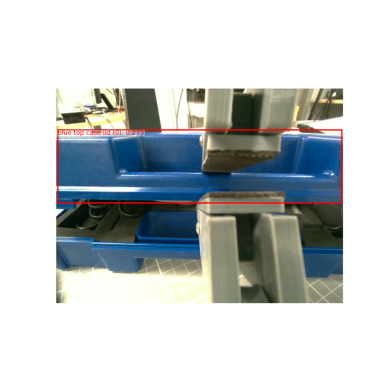

In [50]:
pcd_wrist, rgbd_wrist = wrist.getPCD()
pcd_wkspc, rgbd_wkspc = wkspc.getPCD()

img_wrist = np.array(rgbd_wrist.color).copy()
img_wkspc = np.array(rgbd_wkspc.color)

grasp_prompt = sf_grasp_selection.grasp_prompt.format(**{"user_query": user_query})
img = Image.fromarray(img_wrist)
image_response = gemini_client.models.generate_content(
    model=GEMINI_MODEL_ID,
    contents=[grasp_prompt, img],
)
# image_response = send_message(gemini_client, model=GEMINI_MODEL_ID, messages=[grasp_prompt, img], model_type="gemini")
grasp_phrase = image_response.text.split("\n")[-1].split(": ")[-1]
print(grasp_phrase)

query = [grasp_phrase]
seg_type = 'box-dbscan'
mask_model = mask_models[seg_type]
pcd_wrist, rgbd_wrist = wrist.getPCD()
pose, pred_image = find_object(rgbd_wrist, query, label_model, mask_model, seg_type, wrist)
np.save(f"{LOG_NAME}/init_moveto_pose.npy", pose)
print(pose)
print(plt.get_backend())
%matplotlib inline
plt.imshow(pred_image)
plt.axis('off')  # Optional: to hide axis values and ticks
plt.show()

In [9]:
ROBOT_IP = "192.168.0.4"
robot = ur5.UR5_Interface(ROBOT_IP, 
                            freq=6, # 6Hz frequency
                            record=False,
                            provide_gripper=True,
                            provide_ft_sensor=True,)
robot.start()
robot.start_ft_sensor()
robot.moveL_translation_tooltip(pose, z_offset=0.03, asynch=False)


Found Dynamixel Port:
/dev/ttyACM0

Succeeded to open the port
Succeeded to change the baudrate
Tooltip: [0.012 0.006 0.201]
Goal Pos: [-0.057 -0.352  0.127]


In [7]:
robot.moveL(robot.home, asynch=False)

# Physical Reasoning for Forceful Motion Plan

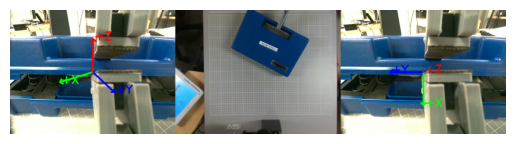

In [51]:
pcd_wkspc, rgbd_wkspc = wkspc.getPCD()
pcd_wrist, rgbd_wrist = wrist.getPCD()
img_wrist = np.array(rgbd_wrist.color)
img_wkspc = np.array(rgbd_wkspc.color)

R_cw = np.array([ # camera to wrist
    [0, -1, 0],
    [1,  0, 0],
    [0,  0, 1]
])
T_wr = np.array(robot.getPose())
R_wr = T_wr[:3, :3]
R_cr = R_cw @ R_wr.T
intrinsics = np.load("scalingforce/intrinsic_matrix.npy", allow_pickle=True)
img_wrist_labeled = label_wrist_image_rotation_axes(img_wrist.copy(), R_cw, intrinsics, axis_length=0.03)
img_wrist_labeled_base = label_wrist_image_rotation_axes(img_wrist.copy(), R_cr, intrinsics, axis_length=0.03)
world_only = np.hstack((img_wrist_labeled_base, img_wkspc))
wrist_only = np.hstack((img_wkspc, img_wrist_labeled))
final_img = np.hstack((img_wrist_labeled_base, img_wkspc, img_wrist_labeled))
# final_img = np.hstack((wrist_img_labeled, wrist_img2_labeled, ))

# save img
fn = f"{LOG_NAME}/init_axes_{user_query}.png"
cv2.imwrite(fn, cv2.cvtColor(final_img, cv2.COLOR_RGB2BGR))

plt.xticks([])
plt.yticks([])
plt.axis('off')
plt.imshow(final_img)

In [52]:
reload_modules(sf_force_thinker, sf_grasp_selection, conversation, sf_force_reflection)
from magpie_prompts.conversation import openai_encode_image, build_messages, send_message

model_type = "gemini"
# model_type = "openai"
client, model = None, None
if model_type == "openai":
    client = openai_client
    model = "gpt-4.1-mini"
    # model = OPENAI_MODEL_ID
elif model_type == "gemini":
    client = gemini_client
    model = GEMINI_MODEL_ID

prompt_config = {
"obj": grasp_phrase,
"task": user_query
}

img = Image.fromarray(final_img)
prompt = sf_force_thinker.prompt_motion_thinker.format(**prompt_config)
MESSAGES = build_messages(prompt, img, messages=MESSAGES, model_type=model_type)
response = send_message(client, model, MESSAGES, model_type=model_type)
motion_plan = force_thinker.process_thinker_response(response)
np.save(f"{LOG_NAME}/response-{STEP}.npy", response, allow_pickle=True)
np.save(f"{LOG_NAME}/motion_plan-{STEP}.npy", motion_plan, allow_pickle=True)
print(response)
MESSAGES = build_messages(response, image=None, messages=MESSAGES, model_type=model_type, role="assistant")
RESPONSES = build_messages(response, image=None, messages=RESPONSES, model_type=model_type)
MOTION_PLANS = build_messages(motion_plan, image=None, messages=MOTION_PLANS, model_type=model_type)
motion_plan

[start of motion plan]
The task is to open the blue case lid while grasping the blue top case lid.

Aligning Images With Wrist Motion:
The provided images in the three-part image confirm the location and orientation of the blue case, its lid, and the robot's end-effector.
The red axis representing the positive world Z-axis corresponds to upward motion in the world. The object in the image is aligned vertically with the upward world Z-axis.
The green axis representing the positive world X-axis corresponds to left-ward motion in the world. The object in the image is aligned horizontally with the left-ward world X-axis.
The blue axis representing the positive world Y-axis corresponds to backward motion in the world. The object in the image is aligned in depth with the backward world Y-axis.
To accomplish the task in the world frame, the object must be moved upwards along the Z-axis and rotated backward to open the lid.
The red dot going into the page representing the positive wrist Z-axis

{'position_direction': [1, 0, 0],
 'position_goal': [0.03, 0.0, 0.0],
 'wrench': [0.0, 0.0, 0.0, 0.0, -0.07, 0.0],
 'grasp_force': 3.5,
 'duration': 2.0}

[{'role': 'user',
  'content': [{'type': 'input_text',
    'text': '\nGiven the user instruction and three-part image containing a wrist-image view on the left, a third-person view in the middle, and another wrist view on the right, generate a structured physical plan for a robot end-effector interacting with the environment.\nThe task is to push the water cup forward 10cm on the table, don\'t know how much water is in it while grasping the Lower body of cup.\n\nThe robot is controlled using position and torque-based control, with access to contact feedback and 6D motion capabilities. \nMotions can include grasping, lifting, pushing, tapping, sliding, rotating, or any interaction with objects or surfaces.\n\nReason about the provided and implicit information in the images and task description to generate a structured plan for the robot\'s motion. Think about:\n- Object geometry and contact points (from the image)\n- Force/torque sensing at the wrist\n- Prior knowledge of object materia
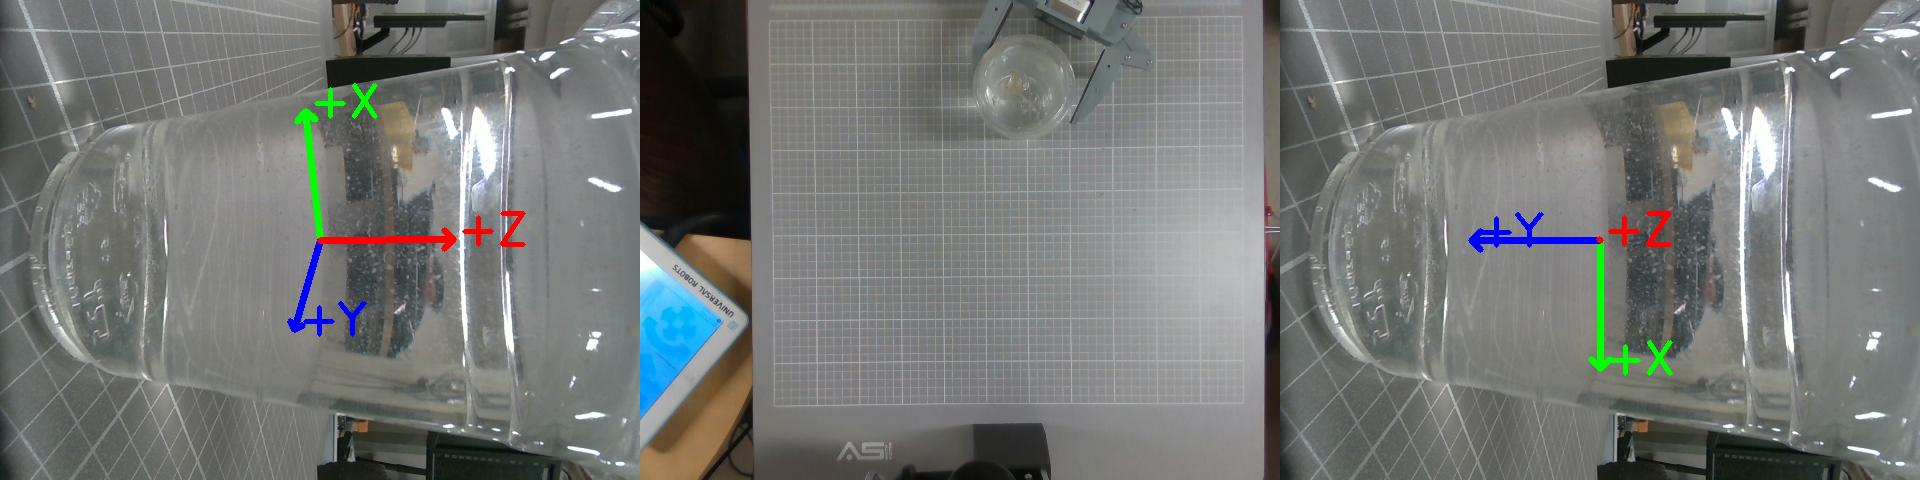

In [34]:
MESSAGES

# Robot Motion Execution

In [48]:
robot.close_gripper()

In [55]:
importlib.reload(ur5)
importlib.reload(gripper)
# ROBOT_IP = "192.168.0.4"
# robot = ur5.UR5_Interface(ROBOT_IP, 
#                             freq=6, # 6Hz frequency
#                             record=False,
#                             provide_gripper=True,
#                             provide_ft_sensor=True,)
# robot.start()
robot.start_ft_sensor(poll_rate=100)
G = robot.gripper
G.reset_parameters()
np.save(f"{LOG_NAME}/init_home.npy", robot.home)
pose = np.load(f"{LOG_NAME}/init_moveto_pose.npy")

[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!


In [59]:
G.reset_and_close_gripper(force_limit=10)

[0.0, 0.0, 0.0, 0.0, -0.07, 0.0]

In [63]:
import numpy as np
motion_plan = np.load(f"{LOG_NAME}/motion_plan-{STEP}.npy", allow_pickle=True).item()
G.reset_and_close_gripper(force_limit=10)
time.sleep(0.25)
print(motion_plan)

camera_dict = {
    wrist: "record/wrist/",
    wkspc: "record/workspace/"
}
goal_delta = np.array(motion_plan['position_goal'])
direction = np.array(motion_plan['position_direction'])
sign = np.where(np.hstack((direction, np.zeros(3))) < 0, -1, 1)
# force = np.array(motion_plan['force']) * sign * -1
wrench = np.array(motion_plan['wrench']) * sign 
wrench_goal = wrench * -1
init_cmd = np.hstack((wrench[:3] / 300, wrench[3:] / 15))
# wrench_goal = np.hstack((force, np.zeros(3)))
# init_cmd = np.hstack((force / -300, np.zeros(3)))
duration = motion_plan['duration']
# duration = 8
grasp_force = motion_plan['grasp_force']
# grasp_force = 10
P = 0.0003 # stiffness gain, default is 0.0005

# TODO: add a re-zero ft sensor function, but for now just restart it
robot.start_ft_sensor()

print(init_cmd)
print(wrench_goal)

motion_log = await robot.concurrent_gripper_camera_robot_control(wrench=wrench_goal, goal_delta=goal_delta, grasp_force=grasp_force, 
                                        #  camera_dict=camera_dict, init_cmd=init_cmd, tolerance=0.01, rerun_viz=rerun_viz,
                                         camera_dict=camera_dict, init_cmd=init_cmd, tolerance=0.01, rerun_viz=None,
                                        #  duration=duration, p=P, control_type="bang_bang")
                                         duration=duration, p=P, control_type="proportional")
robot.ctrl.speedL([0.00, -0.00, 0.00, 0.0, 0.0, 0.0], 0.5, 0.25)
STEP += 1

{'position_direction': [1, 0, 0], 'position_goal': [0.03, 0.0, 0.0], 'wrench': [-2.0, 0.0, 0.0, 0.0, -0.3, 0.0], 'grasp_force': 3.5, 'duration': 2.0}
[-0.007  0.     0.     0.    -0.02   0.   ]
[ 2.  -0.  -0.  -0.   0.3 -0. ]
D405 Recording Started
D435 Recording Started
D405 Recording Task Cancelled
D405 Recording Stopped
D435 Recording Task Cancelled
D435 Recording Stopped


In [16]:
import time
import os
if SAVE:
    episode_time = time.time()
    episode_name = f"{LOG_NAME}/episode_{STEP}_{episode_time}"
    text_messages = [i for i in MESSAGES if type(i) == str]
    # create directory if it doesn't exist
    if not os.path.exists(episode_name):
        os.makedirs(episode_name)
    np.save(f"{episode_name}/query_image.npy", final_img, allow_pickle=True)
    np.save(f"{episode_name}/messages.npy", text_messages, allow_pickle=True)
    np.save(f"{episode_name}/gripper_log.npy", motion_log['gripper'],allow_pickle=True)
    np.save(f"{episode_name}/robot_log.npy", motion_log['robot'],allow_pickle=True)
    np.save(f"{episode_name}/wrist_log.npy", motion_log['record/wrist/'],allow_pickle=True)
    np.save(f"{episode_name}/wkspc_log.npy", motion_log['record/workspace/'],allow_pickle=True)

In [100]:
for key in motion_log:
    ts = motion_log[key].keys()
    last_ts = sorted(ts)[-1]
    first_ts = sorted(ts)[0]
    print(f"sensor {key} first timestamp: {first_ts}")
    print(f"sensor {key} last timestamp: {last_ts}")
    duration = last_ts - first_ts
    length = len(motion_log[key])
    print(f"sensor {key} duration: {duration}, length: {length}, Hz: {length/duration}\n")

sensor gripper first timestamp: 1744653893.7039456
sensor gripper last timestamp: 1744653895.5502605
sensor gripper duration: 1.8463149070739746, length: 12, Hz: 6.499432980811224

sensor robot first timestamp: 1744653893.641354
sensor robot last timestamp: 1744653895.6393583
sensor robot duration: 1.9980041980743408, length: 97, Hz: 48.54844654154769

sensor record/wrist/ first timestamp: 1744653893.5497882
sensor record/wrist/ last timestamp: 1744653895.7499838
sensor record/wrist/ duration: 2.200195550918579, length: 16, Hz: 7.272080880865348

sensor record/workspace/ first timestamp: 1744653893.279495
sensor record/workspace/ last timestamp: 1744653895.6179945
sensor record/workspace/ duration: 2.3384995460510254, length: 15, Hz: 6.414369429889427



# Feedback

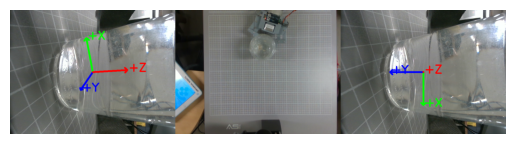

In [130]:
gripper_log = motion_log['gripper'].copy()
robot_log   = motion_log['robot'].copy()
wrist_log   = motion_log['record/wrist/']
wkspc_log   = motion_log['record/workspace/']
gripper_ts   = sorted(gripper_log.keys())
robot_ts     = sorted(robot_log.keys())
wrist_ts     = sorted(wrist_log.keys())
wkspc_ts     = sorted(wkspc_log.keys())

R_cw = np.array([ # camera to wrist
    [0, -1, 0],
    [1,  0, 0],
    [0,  0, 1]
])
T_wr = np.array(sm.SE3(poses.pose_vec_to_mtrx(np.array(robot_log[robot_ts[-1]]['actual_TCP_pose']))))
R_wr = T_wr[:3, :3]
R_cr = R_cw @ R_wr.T
intrinsics = np.load("scalingforce/intrinsic_matrix.npy", allow_pickle=True)
img_wrist_final = wrist_log[wrist_ts[-1]]['rgb']
img_wkspc_final = wkspc_log[wkspc_ts[-1]]['rgb']
img_wrist_final_labeled = label_wrist_image_rotation_axes(img_wrist_final.copy(), R_cw, intrinsics, axis_length=0.03)
img_wrist_final_labeled_base = label_wrist_image_rotation_axes(img_wrist_final.copy(), R_cr, intrinsics, axis_length=0.03)
if STEP == 0:
    prev_img = final_img
else:
    prev_img = feedback_img
feedback_img = np.hstack((img_wrist_final_labeled_base, img_wkspc_final, img_wrist_final_labeled))
# final_img = np.hstack((wrist_img_labeled, wrist_img2_labeled, ))

# save img
fn = f"{LOG_NAME}/axes_step-{STEP}_{user_query}.png"
cv2.imwrite(fn, cv2.cvtColor(final_img, cv2.COLOR_RGB2BGR))

plt.xticks([])
plt.yticks([])
plt.axis('off')
plt.imshow(feedback_img)

In [131]:
from spatialmath.base import rodrigues, tr2rpy
import numpy as np

motion_report = ""
motion_report += f"Initial Motion Plan: {motion_plan}\n"
# get first and last TCP pose of robot log
first_pose = np.array(robot_log[robot_ts[0]]['actual_TCP_pose'])
last_pose =  np.array(robot_log[robot_ts[-1]]['actual_TCP_pose'])
dist =  last_pose - first_pose
# get the rotation matrix from the wrist frame to the robot frame
rot = rodrigues(first_pose[3:6])
# transform distance to be relative to the first TCP wrist frame, use inverse of rot
dist_wrist = rot.T @ dist[:3]
motion_report += f"Motion Plan Results: \nDistance traveled relative to original wrist base frame [x, y, z] (m) axes: {dist_wrist.round(3)}\n"
motion_report += f"Distance traveled along base frame [x, y, z] (m) axes: {dist[:3].round(3)}\n"

# Use a simple moving average with a window size of downsample_factor
def moving_average(data, window_size):
    return np.array([np.mean(data[i:i+window_size], axis=0) for i in range(0, len(data), window_size)])

def get_report(desired_freq, timestamps, log, name, description):
    log_dur = timestamps[-1] - timestamps[0]
    log_flat = np.array([log[i][name] for i in timestamps])
    num_downsampled_entries = int(log_dur // (1 / desired_freq))
    downsample_factor = len(timestamps) // num_downsampled_entries
    downsampled_log = moving_average(log_flat, downsample_factor)
    summary = f"\n{description} Log Summary:"
    summary += f"\nMotion Duration: {log_dur}s"
    summary += f"\nAverage {name} Downsampled at {desired_freq}Hz:"
    for i, entry in enumerate(downsampled_log):
        summary += f"\n{i*(1/desired_freq)}s to {(i+1)*(1/desired_freq)}: {entry.round(2)}"
    summary += f"\nOverall Average Across Episode: {np.mean(downsampled_log, axis=0).round(2)}"
    return summary
desired_freq = 2
# flip the sign of all the wrenches because LLMs do not understand action/reaction
for i in robot_ts:
    robot_log[i]['wrench'] = -1 * np.array(robot_log[i]['wrench'])
wrench_report = get_report(desired_freq, robot_ts, robot_log, "wrench", "6D Wrench [x, y, z, rx, ry, rz] (N and Nm)")
# print(wrench_report)
motion_report += f"{wrench_report}\n"

gripper_report = get_report(desired_freq, gripper_ts, gripper_log, "cf_l", "Left Gripper Contact Force (N)")
motion_report += f"{gripper_report}\n"
gripper_report = get_report(desired_freq, gripper_ts, gripper_log, "cf_r", "Right Gripper Contact Force (N)")
# print(gripper_report)
motion_report += f"{gripper_report}\n"

print(motion_report)

Initial Motion Plan: {'position_direction': [1, 0, 0], 'position_goal': [0.1, 0.0, 0.0], 'wrench': [0.88, 0.0, 0.25, 0.0, 0.0, 0.0], 'grasp_force': 3.0, 'duration': 2.0}
Motion Plan Results: 
Distance traveled relative to original wrist base frame [x, y, z] (m) axes: [0.013 0.    0.024]
Distance traveled along base frame [x, y, z] (m) axes: [-0.021 -0.016 -0.008]

6D Wrench [x, y, z, rx, ry, rz] (N and Nm) Log Summary:
Motion Duration: 1.9989097118377686s
Average wrench Downsampled at 2Hz:
0.0s to 0.5: [ 0.51  0.35 -1.01 -0.02  0.08  0.  ]
0.5s to 1.0: [ 0.39  0.45 -0.84 -0.06  0.07 -0.01]
1.0s to 1.5: [ 0.29  0.1  -0.51 -0.02  0.05 -0.01]
1.5s to 2.0: [ 0.15 -0.3  -0.2   0.01  0.02 -0.01]
Overall Average Across Episode: [ 0.34  0.15 -0.64 -0.02  0.05 -0.01]

Left Gripper Contact Force (N) Log Summary:
Motion Duration: 1.8373091220855713s
Average cf_l Downsampled at 2Hz:
0.0s to 0.5: 1.5
0.5s to 1.0: 1.5
1.0s to 1.5: 1.5
Overall Average Across Episode: 1.5

Right Gripper Contact Force 

In [132]:
from magpie_prompts.prompts import sf_force_thinker, sf_grasp_selection, sf_force_reflection
from magpie_prompts import conversation
reload_modules(conversation, sf_force_thinker, sf_grasp_selection, conversation, sf_force_reflection)
from magpie_prompts.conversation import openai_encode_image, build_messages, send_message

# feedback_messages = messages.copy()
feedback_messages = RESPONSES.copy() # pass by reference now to keep history
feedback_messages = MOTION_PLANS.copy() # pass by reference now to keep history
feedback_prompt_config = prompt_config.copy()
feedback_prompt_config['results'] = motion_report
feedback_prompt = sf_force_reflection.prompt_motion_reflection.format(**feedback_prompt_config)
img_feedback_PIL = Image.fromarray(feedback_img).convert("RGB")
img_previous_PIL = Image.fromarray(prev_img).convert("RGB")
MESSAGES = build_messages(feedback_prompt, img_feedback_PIL, messages=MESSAGES, model_type=model_type)
feedback_messages = build_messages("This is the previous image, taken prior to execution of the robot motion plan", 
                                   img_previous_PIL, messages=feedback_messages, model_type=model_type)
feedback_messages = build_messages(feedback_prompt, img_feedback_PIL, messages=feedback_messages, model_type=model_type)
feedback_response = send_message(client, model, feedback_messages, model_type=model_type)
MESSAGES = build_messages(feedback_response, image=None, messages=MESSAGES, model_type=model_type, role="assistant")
RESPONSES = build_messages(feedback_response, image=None, messages=RESPONSES, model_type=model_type)

print(feedback_response)
force_reflector = sf_force_reflection.PromptForceReflection()
motion_feedback_plan = force_reflector.process_thinker_response(feedback_response)
MOTION_PLANS = build_messages(motion_feedback_plan, image=None, messages=MOTION_PLANS, model_type=model_type)
np.save(f"{LOG_NAME}/response-{STEP}.npy", response, allow_pickle=True)
np.save(f"{LOG_NAME}/motion_plan-{STEP}.npy", motion_plan, allow_pickle=True)
print(motion_feedback_plan)

[beginning of reflection]
Reflection on Task:
- The change in the world X-axis position corresponds to the prior wrist frame motion as such the negative change in the world x-axis indicates the cup moved *away* from the robot, opposite the intended positive wrist frame x-axis motion. This is unexpected and suggests possible slip or miscalculation of the robot's motion due to the water cup not being firmly grasped.
- The change in the world Y-axis position corresponds to the prior wrist frame motion as such the negative change in the world y-axis indicates the cup moved to the left. This is unexpected and indicates possible slip in the gripper.
- The change in the world Z-axis position corresponds to the prior wrist frame motion as such the negative change in the world z-axis indicates the cup moved downwards slightly. This is unexpected and suggests possible slip or miscalculation of the robot's motion due to the water cup not being firmly grasped.
- The change in position relative to 

In [106]:
for i in feedback_messages:
    print(i)

[start of motion plan]
The task is to push the water cup forward 10cm on the table, don't know how much water is in it while grasping the transparent body of cup.

Aligning Images With Wrist Motion:
The provided images in the three-part image confirm the object is a light-colored, likely clear, cup on a table with a gridded surface. The environment includes other objects, but only the cup is relevant. The task requires pushing the cup forward.
The green axis representing the positive X-axis along the wrist corresponds to pushing the cup away from the robot in the world frame.
The blue axis representing negative Y-axis along the wrist corresponds to moving the cup to the right from the robot's perspective in the world frame.
The red dot representing the positive Z-axis (into the page) along the wrist corresponds to moving the cup upwards in the world frame.
Thus, in order to complete the task, the required linear wrist motion along the green axis representing the positive X-axis is posi